# Fault Bucketing — Multi-Iteration Evaluation Harness

Evaluates **one ground-truth labels file** against **one or many predicted
label files** (e.g. v1, v2, v3 of the bucketing pipeline) so prompt /
payload optimisations can be compared side-by-side.

**Inputs**
* `GT_PATH` — `ground_truth_labels.json` (`labels[].related_faults` is the truth)
* `PREDICTION_PATHS` — `{iteration_label: path_to_batch_classification_trace.json}`

**Outputs**
* Per-iteration metrics — exact-match accuracy, Jaccard, micro/macro P/R/F1
* Per-iteration token usage (input + output, summed from each pred file)
* **Final multi-classification comparison table** ranking iterations by F1 / cost
* Per-iteration drill-down — per-class table, confusion table, mismatches with descriptions
* Append-only CSV log + visual trends across iterations


In [14]:
import os, sys
from pathlib import Path

# Repo root from fault_analyzer/tests/evaluation/
REPO_ROOT = Path.cwd().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('Repo root:', REPO_ROOT)


Repo root: C:\Users\meemankgupta\Music\Project\infosys\certifier


In [15]:
%load_ext autoreload
%autoreload 2

import json
import pandas as pd

from fault_analyzer.tests.evaluation.evaluator import (
    evaluate,
    mismatch_table,
    token_cost_report,
    log_iteration,
    load_ground_truth,
    load_predictions,
)

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 220)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 · Configure paths

Add / remove entries in `PREDICTION_PATHS` to evaluate any number of
iterations against the same ground truth.


In [16]:
GT_PATH = Path(
    r'C:\Users\meemankgupta\Music\Project\infosys\certifier'
    r'\data\input\08-05-26-aarya\1960bc89'
    r'\56fe3250-parallel\ground_truth_labels.json'
)

_RUN_BASE = Path(
    r'C:\Users\meemankgupta\Music\Project\infosys\certifier'
    r'\data\output\08-05-26-aarya\1960bc89'
)

PREDICTION_PATHS = {
    'v1-cached-pruned':          _RUN_BASE / '56fe3250-parallel-v1-cached-pruned'          / 'batch_classification_trace.json',
    'v1-cached-pruned-batch4':   _RUN_BASE / '56fe3250-parallel-v1-cached-pruned_batch_4'  / 'batch_classification_trace.json',
    'v1-output-only':            _RUN_BASE / '56fe3250-parallel-v1-output-only'            / 'batch_classification_trace.json',
    'v2-cached-pruned':          _RUN_BASE / '56fe3250-parallel-v2-cached-pruned'          / 'batch_classification_trace.json',
    'v2-cached-pruned-batch4':   _RUN_BASE / '56fe3250-parallel-v2-cached-pruned_batch_4'  / 'batch_classification_trace.json',
    'v2-cached-pruned-batch10':  _RUN_BASE / '56fe3250-parallel-v2-cached-pruned_batch_10' / 'batch_classification_trace.json',
    'v2-output-only':            _RUN_BASE / '56fe3250-parallel-v2-output-only'            / 'batch_classification_trace.json',
    'v2-pruned-toggle':          _RUN_BASE / '56fe3250-parallel-output-v2-pruned'           / 'batch_classification_trace.json',
    'v2-pruned-toggle-batch1':   _RUN_BASE / '56fe3250-parallel-output-v2-pruned_batch_1'   / 'batch_classification_trace.json',
    'v1-default-pipeline':      _RUN_BASE / '56fe3250-parallel-defaults' / '56fe3250-4025-495a-ada1-e619d976969b' / 'fault_buckets' / 'batch_classification_trace.json',
}

# Optional USD pricing per 1k tokens (set both to None to skip cost estimate).
INPUT_PRICE_PER_1K  = 0.0025   # GPT-4o input  (verify against your contract)
OUTPUT_PRICE_PER_1K = 0.01     # GPT-4o output

LOG_PATH = Path('./iteration_log.csv')

## 2 · Load ground truth


In [17]:
manual_labels, gt_descriptions, gt_meta = load_ground_truth(GT_PATH)
print(f"Loaded {len(manual_labels)} GT events for experiment_id={gt_meta['experiment_id']}")
print(f"GT fault catalogue: {list(gt_meta['faults'].keys())}")


Loaded 50 GT events for experiment_id=56fe3250-4025-495a-ada1-e619d976969b
GT fault catalogue: ['pod-cpu-hog', 'pod-network-loss', 'pod-memory-hog']


## 3 · Evaluate every prediction file against the GT

Iterates through `PREDICTION_PATHS`, loads each prediction file (using its
own `tokens_in`/`tokens_out` per event), merges descriptions (preferring
GT's `labeling_notes` when present), runs `evaluate()`, and appends the
row to the CSV log.


In [18]:
results = {}   # iteration_label -> EvaluationResult
loaded   = {}  # iteration_label -> dict(predictions, descriptions, tokens, meta)

for label, path in PREDICTION_PATHS.items():
    if not Path(path).exists():
        print(f'[skip] {label}: file not found -> {path}')
        continue
    preds, pred_descs, tokens, pmeta = load_predictions(path)
    # Prefer GT descriptions for triage, fall back to per-event prediction descriptions
    descriptions = {**pred_descs, **{k: v for k, v in gt_descriptions.items() if v}}
    result = evaluate(
        manual_labels      = manual_labels,
        predicted_labels   = preds,
        descriptions       = descriptions,
        input_tokens       = tokens['input_tokens'],
        output_tokens      = tokens['output_tokens'],
        input_price_per_1k = INPUT_PRICE_PER_1K,
        output_price_per_1k= OUTPUT_PRICE_PER_1K,
        iteration_label    = label,
        metadata = {
            'gt_path':   str(GT_PATH),
            'pred_path': str(path),
            'experiment_id': gt_meta['experiment_id'],
            'n_pred_events':       pmeta['n_events'],
            'n_llm_classified':    pmeta['n_llm_classified'],
            'n_deterministic':     pmeta['n_deterministic'],
        },
    )
    results[label] = result
    loaded[label]  = {
        'predictions':  preds,
        'descriptions': descriptions,
        'tokens':       tokens,
        'meta':         pmeta,
    }
    log_iteration(result, LOG_PATH)
    print(f"  - {label:24s}  evaluated {result.n_evaluated:3d} events  "
          f"exact={result.exact_match_accuracy:.3f}  microF1={result.micro_f1:.3f}  "
          f"tokens in/out={result.total_input_tokens}/{result.total_output_tokens}")

print(f'\nLogged {len(results)} iterations -> {LOG_PATH.resolve()}')


  - v1-cached-pruned          evaluated  50 events  exact=0.860  microF1=0.932  tokens in/out=526144/11675
  - v1-cached-pruned-batch4   evaluated  50 events  exact=0.900  microF1=0.942  tokens in/out=618540/38256
  - v1-output-only            evaluated  50 events  exact=0.760  microF1=0.878  tokens in/out=625084/13566
  - v2-cached-pruned          evaluated  50 events  exact=0.880  microF1=0.927  tokens in/out=494575/11848
  - v2-cached-pruned-batch4   evaluated  50 events  exact=0.900  microF1=0.952  tokens in/out=586284/38120
  - v2-cached-pruned-batch10  evaluated  50 events  exact=0.920  microF1=0.962  tokens in/out=754868/83120
  - v2-output-only            evaluated  50 events  exact=0.920  microF1=0.962  tokens in/out=588155/13090
  - v2-pruned-toggle          evaluated  50 events  exact=0.560  microF1=0.659  tokens in/out=60601/8849
  - v2-pruned-toggle-batch1   evaluated  50 events  exact=0.640  microF1=0.782  tokens in/out=210442/11588
  - v1-default-pipeline       evaluated

## 4 · Final multi-classification comparison

One row per iteration. Sorted by `micro_f1` desc, then by
`total_tokens` asc — best quality at lowest cost first. This is the
headline outcome for prompt-optimisation rounds.


In [19]:
comparison_rows = []
for label, r in results.items():
    comparison_rows.append({
        'iteration':            label,
        'n_evaluated':          r.n_evaluated,
        'exact_match':          round(r.exact_match_accuracy, 4),
        'mean_jaccard':         round(r.mean_jaccard, 4),
        'micro_precision':      round(r.micro_precision, 4),
        'micro_recall':         round(r.micro_recall, 4),
        'micro_f1':             round(r.micro_f1, 4),
        'macro_f1':             round(r.macro_f1, 4),
        'input_tokens':         r.total_input_tokens,
        'output_tokens':        r.total_output_tokens,
        'total_tokens':         r.total_tokens,
        'estimated_cost_usd':   (round(r.estimated_cost_usd, 4)
                                  if r.estimated_cost_usd is not None else None),
        'n_only_manual':        r.n_only_manual,
        'n_only_predicted':     r.n_only_predicted,
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
      .sort_values(['micro_f1', 'total_tokens'], ascending=[False, True])
      .reset_index(drop=True)
)
comparison_df


,iteration,n_evaluated,exact_match,mean_jaccard,micro_precision,micro_recall,micro_f1,macro_f1,input_tokens,output_tokens,total_tokens,estimated_cost_usd,n_only_manual,n_only_predicted
0,v2-output-only,50,0.92,0.9200,1.0000,0.9273,0.9623,0.9614,588155,13090,601245,1.6013,0,0
1,v2-cached-pruned-batch10,50,0.92,0.9200,1.0000,0.9273,0.9623,0.9614,754868,83120,837988,2.7184,0,0
2,v2-cached-pruned-batch4,50,0.90,0.9000,1.0000,0.9091,0.9524,0.9552,586284,38120,624404,1.8469,0,0
3,v1-default-pipeline,50,0.90,0.9067,0.9623,0.9273,0.9444,0.9368,840369,12648,853017,2.2274,0,0
4,v1-cached-pruned-batch4,50,0.90,0.9067,1.0000,0.8909,0.9423,0.9325,618540,38256,656796,1.9289,0,0
5,v1-cached-pruned,50,0.86,0.8600,1.0000,0.8727,0.9320,0.9419,526144,11675,537819,1.4321,0,0
6,v2-cached-pruned,50,0.88,0.8933,0.9273,0.9273,0.9273,0.9140,494575,11848,506423,1.3549,0,0
7,v1-output-only,50,0.76,0.7600,1.0000,0.7818,0.8776,0.9039,625084,13566,638650,1.6984,0,0
8,v2-pruned-toggle-batch1,50,0.64,0.6800,0.7818,0.7818,0.7818,0.7800,210442,11588,222030,0.6420,0,0
9,v2-pruned-toggle,50,0.56,0.5800,0.8333,0.5455,0.6593,0.6751,60601,8849,69450,0.2400,0,0


In [20]:
# Δ vs. baseline (= first row of PREDICTION_PATHS)
baseline_label = next(iter(PREDICTION_PATHS))
if baseline_label in results:
    base = results[baseline_label]
    delta_rows = []
    for label, r in results.items():
        delta_rows.append({
            'iteration':            label,
            'd_exact_match':        round(r.exact_match_accuracy - base.exact_match_accuracy, 4),
            'd_micro_f1':           round(r.micro_f1            - base.micro_f1,            4),
            'd_macro_f1':           round(r.macro_f1            - base.macro_f1,            4),
            'd_input_tokens':       r.total_input_tokens  - base.total_input_tokens,
            'd_output_tokens':      r.total_output_tokens - base.total_output_tokens,
            'd_total_tokens':       r.total_tokens        - base.total_tokens,
            'input_token_pct':      (None if base.total_input_tokens == 0
                                     else round(100*(r.total_input_tokens - base.total_input_tokens)/base.total_input_tokens, 2)),
        })
    delta_df = pd.DataFrame(delta_rows)
    print(f'Δ relative to baseline: {baseline_label}')
    display(delta_df)


Δ relative to baseline: v1-cached-pruned


,iteration,d_exact_match,d_micro_f1,d_macro_f1,d_input_tokens,d_output_tokens,d_total_tokens,input_token_pct
0,v1-cached-pruned,0.00,0.0000,0.0000,0,0,0,0.00
1,v1-cached-pruned-batch4,0.04,0.0103,-0.0093,92396,26581,118977,17.56
2,v1-output-only,-0.10,-0.0545,-0.0380,98940,1891,100831,18.80
3,v2-cached-pruned,0.02,-0.0048,-0.0279,-31569,173,-31396,-6.00
4,v2-cached-pruned-batch4,0.04,0.0203,0.0133,60140,26445,86585,11.43
5,v2-cached-pruned-batch10,0.06,0.0302,0.0195,228724,71445,300169,43.47
6,v2-output-only,0.06,0.0302,0.0195,62011,1415,63426,11.79
7,v2-pruned-toggle,-0.30,-0.2727,-0.2668,-465543,-2826,-468369,-88.48
8,v2-pruned-toggle-batch1,-0.22,-0.1502,-0.1619,-315702,-87,-315789,-60.00
9,v1-default-pipeline,0.04,0.0124,-0.0051,314225,973,315198,59.72


## 5 · Per-iteration drill-down

Pick an iteration label to inspect per-class metrics, the pairwise
confusion table, and the mismatch triage list (worst-first, with
descriptions).


In [21]:
INSPECT = list(results.keys())[-1] if results else None   # change to any key in PREDICTION_PATHS
INSPECT


'v1-default-pipeline'

In [22]:
if INSPECT and INSPECT in results:
    r = results[INSPECT]
    per_class_df = pd.DataFrame(r.per_class).T.sort_values('support', ascending=False)
    display(per_class_df)
else:
    print('Set INSPECT to a key from PREDICTION_PATHS.')


,tp,fp,fn,support,precision,recall,f1
pod-network-loss,27.0,0.0,2.0,29.0,1.000000,0.931034,0.964286
pod-memory-hog,12.0,1.0,1.0,13.0,0.923077,0.923077,0.923077
pod-cpu-hog,12.0,1.0,1.0,13.0,0.923077,0.923077,0.923077


### Pairwise confusion (rows = manual, cols = predicted)

* `__missed__` column = manual label with no prediction (recall loss)
* `__spurious__` row = predicted label with no matching manual (precision loss)
* `__none__` row = events the human marked as no-fault but model predicted one


In [23]:
if INSPECT and INSPECT in results:
    r = results[INSPECT]
    confusion_df = pd.DataFrame(r.confusion).T.fillna(0).astype(int)
    display(confusion_df)


,__missed__,pod-cpu-hog,pod-memory-hog,pod-network-loss
pod-cpu-hog,1,12,11,11
pod-network-loss,2,12,12,27
pod-memory-hog,1,11,12,11
__spurious__,0,1,1,0


### Mismatch triage — worst predictions first

Use these rows to decide what to change in the next prompt iteration
(disambiguation rule, payload trim, few-shot example, ...).


In [24]:
if INSPECT and INSPECT in results:
    info = loaded[INSPECT]
    mismatches = mismatch_table(
        manual_labels,
        info['predictions'],
        info['descriptions'],
        only_mismatches=True,
    )
    display(mismatches)


,event_id,manual,predicted,missed,spurious,exact_match,jaccard,description
0,06522d56-9bd2-4dc5-a3a9-906874a81cbe-demoexp-i2-4-par-1778226949449-2354373000,[pod-cpu-hog],[],[pod-cpu-hog],[],False,0.0000,workflow-step: pod-cpu-hog | workflow-step name explicitly identifies pod-cpu-hog. Definitionally related to that fault. V1 correct; V2 ...
1,06522d56-9bd2-4dc5-a3a9-906874a81cbe-demoexp-i2-4-par-1778226949449-2598008181,[pod-network-loss],[],[pod-network-loss],[],False,0.0000,workflow-step: pod-network-loss | workflow-step name explicitly identifies pod-network-loss. Definitionally related. V1 correct; V2 inco...
2,06522d56-9bd2-4dc5-a3a9-906874a81cbe-demoexp-i2-4-par-1778226949449-577757239,[pod-memory-hog],[],[pod-memory-hog],[],False,0.0000,workflow-step: pod-memory-hog | workflow-step name explicitly identifies pod-memory-hog. Definitionally related. V1 correct; V2 incorrec...
3,time-07-59-41-573811_chatcmpl-DdAPV5utfIz4UkwOS70dLxRbssqMU,[pod-network-loss],[],[pod-network-loss],[],False,0.0000,"litellm-acompletion | GENERATION monologue; user-5bc44bf4bf-2b47s pod shows 0/1 Ready, 1 restart, multiple liveness/readiness probe fail..."
4,time-08-00-42-270713_chatcmpl-DdAQUU7kB58Hn1DjRIu9Osaue1upN,[pod-network-loss],"[pod-cpu-hog, pod-memory-hog, pod-network-loss]",[],"[pod-cpu-hog, pod-memory-hog]",False,0.3333,"litellm-acompletion | GENERATION with tool_calls targeting user pod: pods_get(user-5bc44bf4bf-2b47s), pods_log(user-5bc44bf4bf-2b47s). R..."


## 6 · Cross-iteration trends

Reads the persistent CSV log (so historical runs from earlier sessions
are included) and renders quality + token charts.


In [25]:
if LOG_PATH.exists():
    log_df = pd.read_csv(LOG_PATH)
    cols = [
        'iteration_label', 'timestamp',
        'exact_match_accuracy', 'mean_jaccard',
        'micro_f1', 'macro_f1',
        'total_input_tokens', 'total_output_tokens', 'total_tokens',
        'estimated_cost_usd',
    ]
    display(log_df[cols].tail(30))
else:
    print('No iteration log yet.')


,iteration_label,timestamp,exact_match_accuracy,mean_jaccard,micro_f1,macro_f1,total_input_tokens,total_output_tokens,total_tokens,estimated_cost_usd
24,v2-cached-pruned-batch10,2026-05-09T17:49:28+00:00,0.92,0.920000,0.962264,0.961429,754868,83120,837988,2.718370
25,v2-output-only,2026-05-09T17:49:28+00:00,0.92,0.920000,0.962264,0.961429,588155,13090,601245,1.601287
26,v1-cached-pruned,2026-05-11T11:02:07+00:00,0.86,0.860000,0.932039,0.941887,526144,11675,537819,1.432110
27,v1-cached-pruned-batch4,2026-05-11T11:02:07+00:00,0.90,0.906667,0.942308,0.932540,618540,38256,656796,1.928910
28,v1-output-only,2026-05-11T11:02:07+00:00,0.76,0.760000,0.877551,0.903889,625084,13566,638650,1.698370
29,v2-cached-pruned,2026-05-11T11:02:07+00:00,0.88,0.893333,0.927273,0.914021,494575,11848,506423,1.354917
30,v2-cached-pruned-batch4,2026-05-11T11:02:08+00:00,0.90,0.900000,0.952381,0.955152,586284,38120,624404,1.846910
31,v2-cached-pruned-batch10,2026-05-11T11:02:08+00:00,0.92,0.920000,0.962264,0.961429,754868,83120,837988,2.718370
32,v2-output-only,2026-05-11T11:02:08+00:00,0.92,0.920000,0.962264,0.961429,588155,13090,601245,1.601287
33,v2-pruned-toggle,2026-05-11T11:02:08+00:00,0.56,0.580000,0.659341,0.675122,60601,8849,69450,0.239992


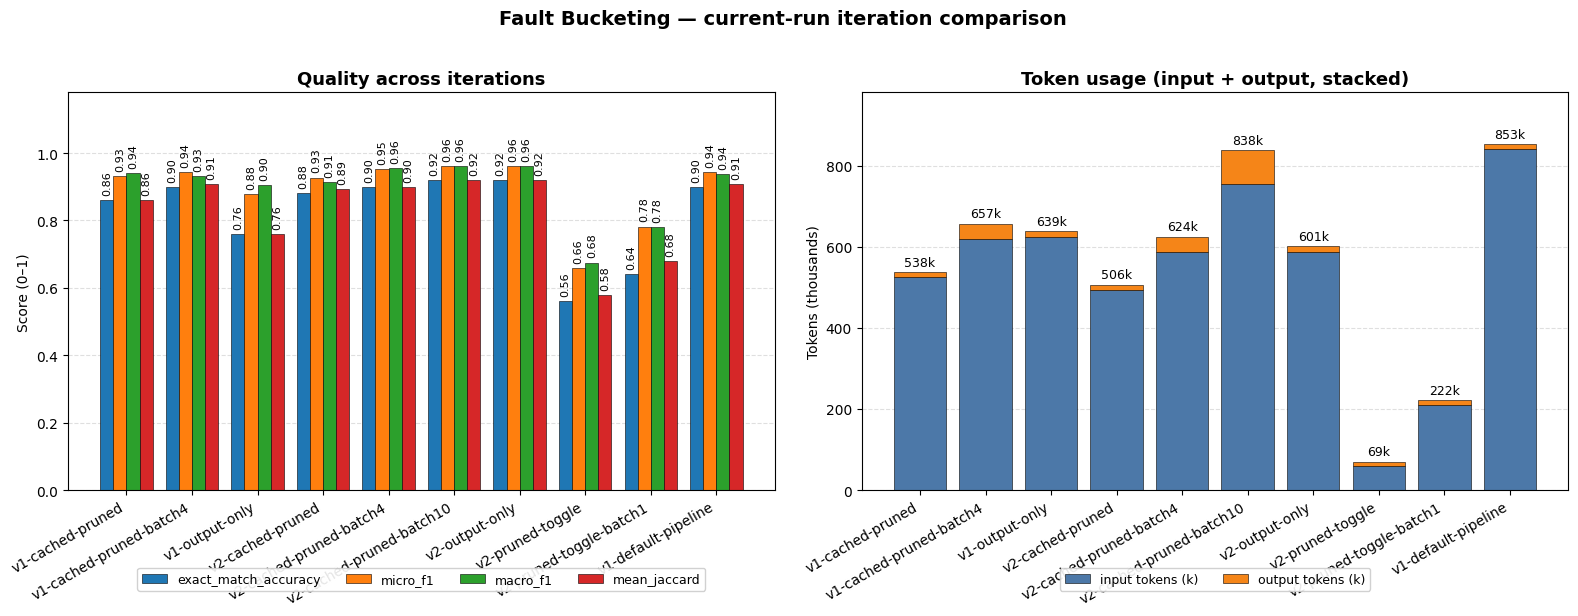

In [26]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    if results:
        # Plot only the CURRENT run's results (dedup by iteration label).
        # The CSV log accumulates rows across sessions and would duplicate bars.
        labels = list(results.keys())
        rows = []
        for lbl in labels:
            r = results[lbl]
            rows.append({
                'iteration_label':      lbl,
                'exact_match_accuracy': r.exact_match_accuracy,
                'micro_f1':             r.micro_f1,
                'macro_f1':             r.macro_f1,
                'mean_jaccard':         r.mean_jaccard,
                'total_input_tokens':   r.total_input_tokens,
                'total_output_tokens':  r.total_output_tokens,
            })
        plot_df = pd.DataFrame(rows)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        x = np.arange(len(plot_df))

        # ---- Quality panel: grouped bars ----
        quality_metrics = ['exact_match_accuracy', 'micro_f1', 'macro_f1', 'mean_jaccard']
        bar_w = 0.20
        colors_q = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        for i, metric in enumerate(quality_metrics):
            offset = (i - (len(quality_metrics) - 1) / 2) * bar_w
            bars = axes[0].bar(x + offset, plot_df[metric], bar_w,
                               label=metric, color=colors_q[i],
                               edgecolor='black', linewidth=0.4)
            for b in bars:
                axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015,
                             f"{b.get_height():.2f}", ha='center', va='bottom',
                             fontsize=8, rotation=90)

        axes[0].set_xticks(x)
        axes[0].set_xticklabels(plot_df['iteration_label'], rotation=30, ha='right', fontsize=10)
        axes[0].set_ylim(0, 1.18)
        axes[0].set_ylabel('Score (0–1)')
        axes[0].set_title('Quality across iterations', fontsize=13, fontweight='bold')
        axes[0].legend(loc='upper center', ncol=4, fontsize=9,
                       bbox_to_anchor=(0.5, -0.18), framealpha=0.9)
        axes[0].grid(axis='y', linestyle='--', alpha=0.4)
        axes[0].set_axisbelow(True)

        # ---- Tokens panel: stacked bars ----
        tokens_in_k = plot_df['total_input_tokens'] / 1000.0
        tokens_out_k = plot_df['total_output_tokens'] / 1000.0
        axes[1].bar(x, tokens_in_k, label='input tokens (k)',
                    color='#4c78a8', edgecolor='black', linewidth=0.4)
        axes[1].bar(x, tokens_out_k, bottom=tokens_in_k, label='output tokens (k)',
                    color='#f58518', edgecolor='black', linewidth=0.4)
        ymax = (tokens_in_k + tokens_out_k).max()
        for xi, (ti, to) in enumerate(zip(tokens_in_k, tokens_out_k)):
            axes[1].text(xi, ti + to + ymax * 0.01,
                         f"{ti + to:,.0f}k", ha='center', va='bottom', fontsize=9)

        axes[1].set_xticks(x)
        axes[1].set_xticklabels(plot_df['iteration_label'], rotation=30, ha='right', fontsize=10)
        axes[1].set_ylim(0, ymax * 1.15)
        axes[1].set_ylabel('Tokens (thousands)')
        axes[1].set_title('Token usage (input + output, stacked)', fontsize=13, fontweight='bold')
        axes[1].legend(loc='upper center', ncol=2, fontsize=9,
                       bbox_to_anchor=(0.5, -0.18), framealpha=0.9)
        axes[1].grid(axis='y', linestyle='--', alpha=0.4)
        axes[1].set_axisbelow(True)

        plt.suptitle('Fault Bucketing — current-run iteration comparison',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print('No results to plot — run the evaluation cell first.')
except ImportError:
    print('matplotlib not installed — skipping plots.')